# Step 1: Define the 3D Cube Vertices

In [1]:
import numpy as np

In [2]:
# Define the 8 vertices of the cube
cube_vertices = np.array([
    [-1, -1, -1],  # v1
    [ 1, -1, -1],  # v2
    [ 1,  1, -1],  # v3
    [-1,  1, -1],  # v4
    [-1, -1,  1],  # v5
    [ 1, -1,  1],  # v6
    [ 1,  1,  1],  # v7
    [-1,  1,  1],  # v8
])

# Step 2: Rotate the cube around the Y-axis

In [3]:
# Function to rotate vertices around Y-axis by a given angle in degrees
def rotate_y(vertices, angle_degrees):
    angle_rad = np.radians(angle_degrees)  # Convert degrees to radians
    rotation_matrix = np.array([
        [np.cos(angle_rad), 0, np.sin(angle_rad)],
        [0, 1, 0],
        [-np.sin(angle_rad), 0, np.cos(angle_rad)]
    ])
    # Apply rotation to each vertex
    return vertices @ rotation_matrix.T

#  Step 3: Apply Perspective Projection

In [4]:
# Function to project 3D vertices to 2D using perspective projection
def perspective_projection(vertices, camera_pos):
    projected = []
    for vertex in vertices:
        # Calculate relative position of the vertex to the camera
        relative = vertex - camera_pos

        # Avoid division by zero
        if relative[2] == 0:
            relative[2] = 1e-5

        # Apply perspective projection formula
        x_proj = relative[0] / relative[2]
        y_proj = relative[1] / relative[2]
        projected.append([x_proj, y_proj])
    
    return np.array(projected)

# Step 4: Visualize the 2D Projected Cube

In [5]:
import matplotlib.pyplot as plt

In [6]:
# Define the edges of the cube (pairs of vertex indices)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # back face
    (4, 5), (5, 6), (6, 7), (7, 4),  # front face
    (0, 4), (1, 5), (2, 6), (3, 7)   # sides
]

In [7]:
def plot_projected_cube(projected_2d, angle):
    plt.figure()
    for edge in edges:
        p1 = projected_2d[edge[0]]
        p2 = projected_2d[edge[1]]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'bo-')  # blue line with dots

    plt.title(f'Perspective Projection (Y Rotation = {angle}°)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Finally: Run the full process for 0°, 45°, and 90°:

In [8]:
camera_position = np.array([5, 5, 5])

In [9]:
angles = [0, 45, 90]

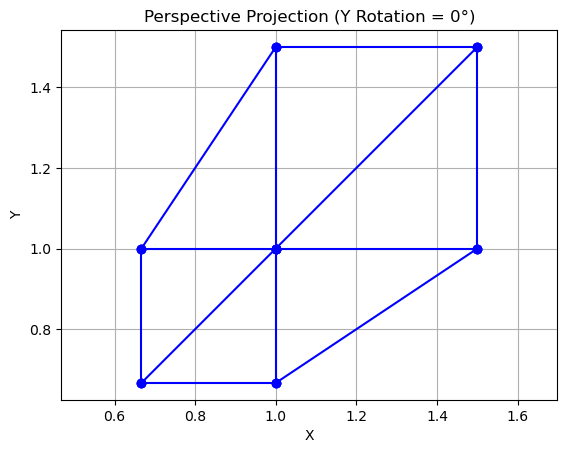

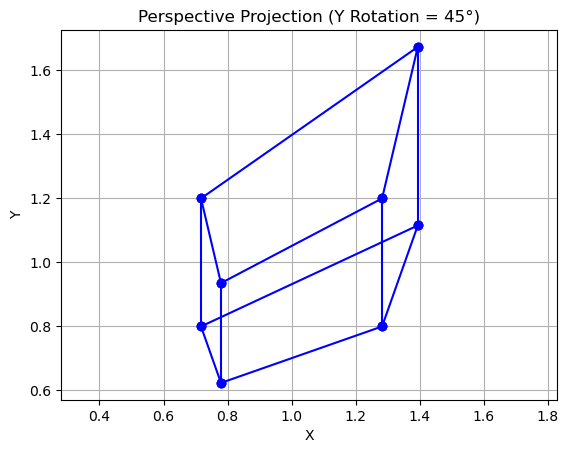

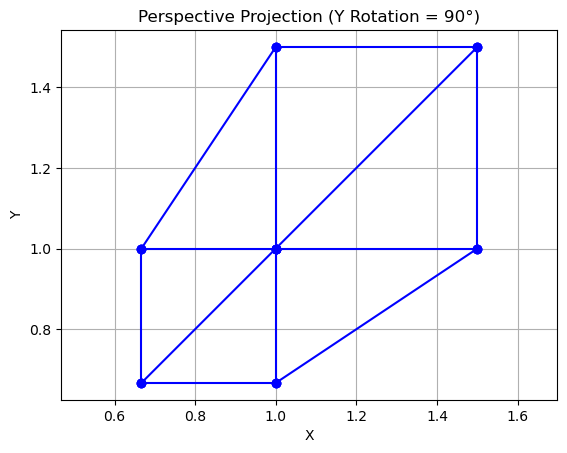

In [10]:
for angle in angles:
    rotated = rotate_y(cube_vertices, angle)
    projected = perspective_projection(rotated, camera_position)
    plot_projected_cube(projected, angle)